- [] Analyze category correlation to views/likes/dislikes etc
- [] Analyze relationship between US category popularity and other countries

### ToDo:
- Evolution of Category popularity over time in some capacity (days, weeks, whatever)
- Correlation between category and likes/dislikes
- Correlation between category and comment count
- Correlation between category and all numerics lmao
- Compare above information to other countries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

us_df = pd.read_csv("data/USvideos.csv")
us_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [11]:
def make_tag_dict(filepath):
    cat = pd.read_json(filepath)
    new_dict = {}
    for i in range(len(cat["items"])):
        new_dict[cat["items"][i]["id"]] = cat["items"][i]["snippet"]["title"]
    
    return new_dict

fetch_dict = make_tag_dict("data/US_category_id.json")

def fetch_tag(category_id):
    return fetch_dict[str(category_id)]

print(fetch_tag("43"))

Shows


In [12]:
us_df["category_name"] = us_df["category_id"].apply(fetch_tag)

us_df.sample(5)



,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
34240,Wpm07-BGJnE,18.12.05,Nicki Minaj - Chun-Li,NickiMinajAtVEVO,10,2018-05-04T16:00:08.000Z,"Nicki|""Minaj""|""Chun-Li""|""Minaj/Cash""|""Money""|""...",26068468,734531,79421,86622,https://i.ytimg.com/vi/Wpm07-BGJnE/default.jpg,False,False,False,Chun-Li (Official Video)Song Available Here: h...,Music
2368,Y1n8F4uClUU,17.25.11,FIA GT World Cup 2017. Qualification Race Maca...,CrashRacing,2,2017-11-18T04:57:43.000Z,"GT Series|""Qualification Race""|""Macau Grand Pr...",3393569,17209,1082,2778,https://i.ytimg.com/vi/Y1n8F4uClUU/default.jpg,False,False,False,Meanwhile in Macau,Autos & Vehicles
4790,ZfHiw_LFNGw,17.07.12,Kylie Jenner Pregnancy Reveal On Keeping Up Wi...,HollywoodLife,24,2017-11-29T00:35:32.000Z,"kylie jenner|""kendall jenner""|""pregnant""|""preg...",5545698,23966,7807,3308,https://i.ytimg.com/vi/ZfHiw_LFNGw/default.jpg,False,False,False,Kylie Jenner may reveal her pregnancy on Keepi...,Entertainment
35269,UE-kaxIiNPQ,18.17.05,Rihanna on Her Divine Dress and Co-Hosting Wit...,Vogue,26,2018-05-08T01:27:08.000Z,"liza|""liza koshy""|""met gala""|""the met""|""met ga...",2462729,68071,1472,2710,https://i.ytimg.com/vi/UE-kaxIiNPQ/default.jpg,False,False,False,Rihanna talks with Liza Koshy about her beaded...,Howto & Style
29639,8hYTPl7MkiA,18.19.04,How to Stop Being a People Pleaser,The School of Life,27,2018-04-12T12:56:39.000Z,"the school of life|""alain de botton""|""self""|""i...",323133,12334,217,720,https://i.ytimg.com/vi/8hYTPl7MkiA/default.jpg,False,False,False,The first 500 people to click this link will g...,Education


<Axes: ylabel='category_name'>

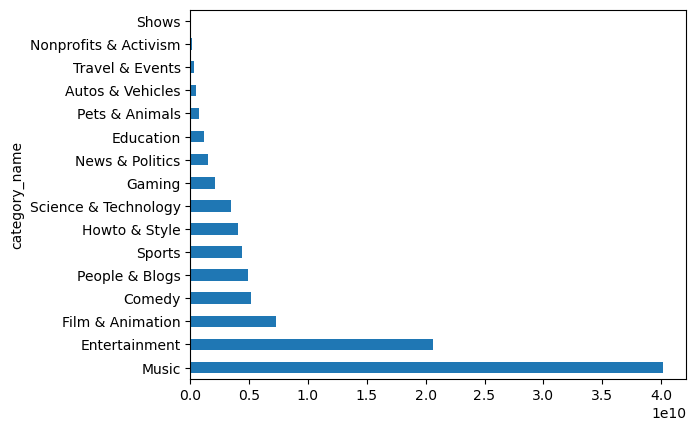

In [13]:
us_df_reduced = us_df.drop(columns=["thumbnail_link", "video_id", "comments_disabled", "description", "ratings_disabled", "video_error_or_removed"])
us_df_reduced["trending_date"] = pd.to_datetime(us_df_reduced["trending_date"], format="%y.%d.%m")
us_df_reduced["publish_time"] = pd.to_datetime(us_df_reduced["publish_time"])
us_df_reduced.sort_values("trending_date", ascending=False)
us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False)

us_df_reduced.groupby("category_name")["views"].sum().sort_values(ascending=False).plot(kind="barh")

In [14]:
us_df_reduced.groupby("category_id")["views"].sum().sort_values(ascending=False)

us_df_reduced.corr(numeric_only=True)


,category_id,views,likes,dislikes,comment_count
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307
views,-0.168231,1.000000,0.849177,0.472213,0.617621
likes,-0.173921,0.849177,1.000000,0.447186,0.803057
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000


<Axes: ylabel='category_name'>

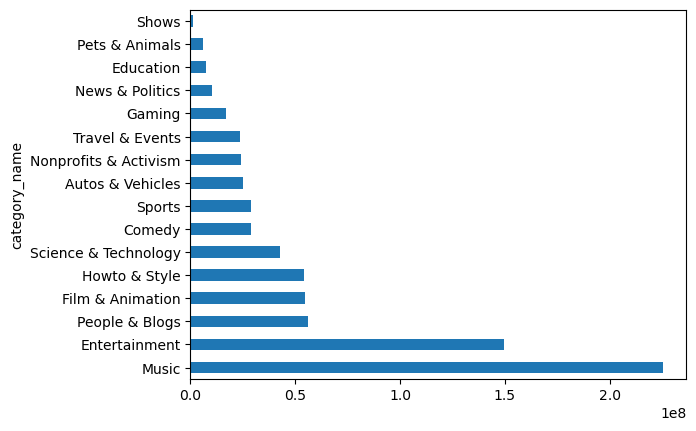

In [15]:
most_viewed_in_each_category = us_df_reduced.groupby("category_name")["views"].max().sort_values(ascending=False)
most_viewed_in_each_category.plot(kind="barh")

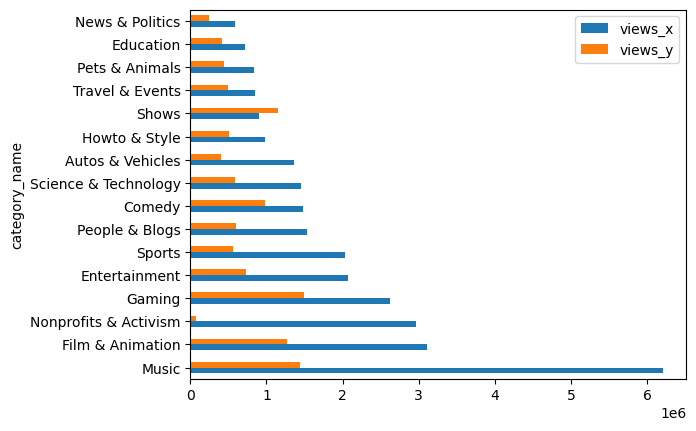

In [16]:
cat_view_mean = us_df_reduced.groupby("category_name")["views"].mean().sort_values(ascending=False)
cat_view_median = us_df_reduced.groupby("category_name")["views"].median().sort_values(ascending=False)

pd.merge(cat_view_mean, cat_view_median, on="category_name").plot(kind="barh")

plt.show()


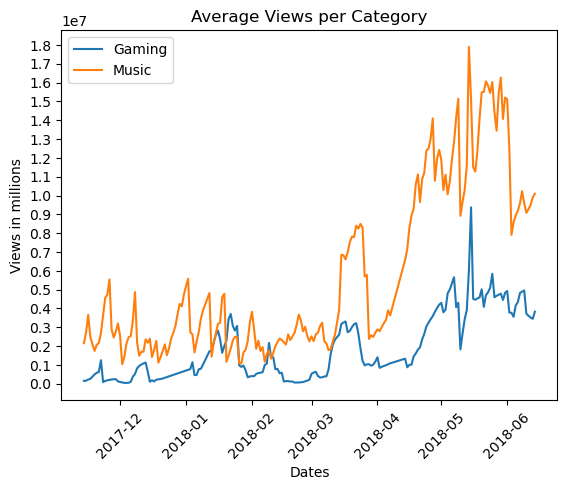

In [17]:
us_df_gaming = us_df_reduced[us_df_reduced["category_name"] == "Gaming"].groupby("trending_date")["views"].mean()
us_df_music = us_df_reduced[us_df_reduced["category_name"] == "Music"].groupby("trending_date")["views"].mean()
us_df_gaming = us_df_gaming.reset_index()
us_df_music = us_df_music.reset_index()

plt.plot(us_df_gaming["trending_date"], us_df_gaming["views"], label="Gaming")
plt.plot(us_df_music["trending_date"], us_df_music["views"], label="Music")
plt.yticks(np.arange(0, round(us_df_music["views"].max(), -6) + 1000000, 1000000))
plt.title("Average Views per Category")
plt.ylabel("Views in millions")
plt.xlabel("Dates")
plt.xticks(rotation=45)
plt.legend()

Replicate this plotting process as a function:

Function should accept a list of categories and a dataframe for whatever country we want to see.

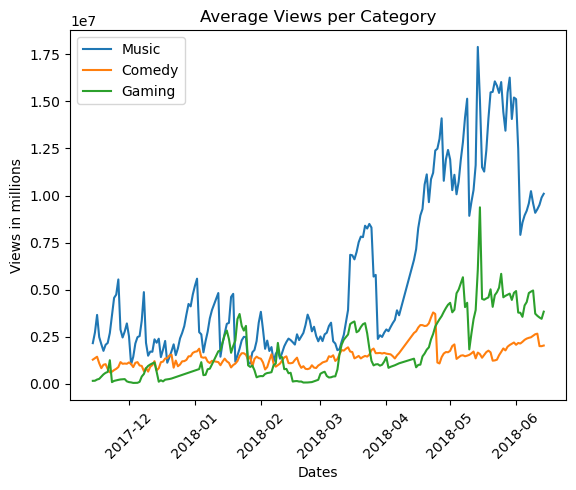

'\nus_df_gaming = us_df_reduced[us_df_reduced["category_name"] == "Gaming"].groupby("trending_date")["views"].mean()\nus_df_music = us_df_reduced[us_df_reduced["category_name"] == "Music"].groupby("trending_date")["views"].mean()\nus_df_gaming = us_df_gaming.reset_index()\nus_df_music = us_df_music.reset_index()\n\nplt.plot(us_df_gaming["trending_date"], us_df_gaming["views"], label="Gaming")\nplt.plot(us_df_music["trending_date"], us_df_music["views"], label="Music")\nplt.yticks(np.arange(0, round(us_df_music["views"].max(), -6) + 1000000, 1000000))\nplt.title("Average Views per Category")\nplt.ylabel("Views in millions")\nplt.xlabel("Dates")\nplt.xticks(rotation=45)\nplt.legend()\n'

In [25]:
def plot_categories(df, category, aggregation='mean'):
        df = df[df["category_name"] == category].groupby("trending_date")["views"].mean()
        df = df.reset_index()
        ax = plt.plot(df["trending_date"], df["views"], label=category)
        return ax

cat_list = ['Music', "Comedy", "Gaming"]
for cat in cat_list:
    plot_categories(us_df_reduced, cat)
plt.legend()
plt.title("Average Views per Category")
plt.ylabel("Views in millions")
plt.xlabel("Dates")
plt.xticks(rotation=45)
plt.show()
'''
us_df_gaming = us_df_reduced[us_df_reduced["category_name"] == "Gaming"].groupby("trending_date")["views"].mean()
us_df_music = us_df_reduced[us_df_reduced["category_name"] == "Music"].groupby("trending_date")["views"].mean()
us_df_gaming = us_df_gaming.reset_index()
us_df_music = us_df_music.reset_index()

plt.plot(us_df_gaming["trending_date"], us_df_gaming["views"], label="Gaming")
plt.plot(us_df_music["trending_date"], us_df_music["views"], label="Music")
plt.yticks(np.arange(0, round(us_df_music["views"].max(), -6) + 1000000, 1000000))
plt.title("Average Views per Category")
plt.ylabel("Views in millions")
plt.xlabel("Dates")
plt.xticks(rotation=45)
plt.legend()
'''